In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, next_fast_len
from obspy.core import read, Trace
from obspy.core import Stream
from glob import glob
from obspy.signal import PPSD
from pathlib import Path
import obspy

def plot_spectrum(tr):
    """Plot spectrum of ObsPy trace"""
    #tr.detrend('demean')
    #tr.taper(0.5, 'hann')   
    sr = tr.stats.sampling_rate
    nfft = next_fast_len(tr.stats.npts)  # pad data with zeros for fast FT
    pos_freq = (nfft + 1) // 2  # index for positive frequencies
    spec = fft(tr.data, nfft)[:pos_freq]
    freq = fftfreq(nfft, 1 / sr)[:pos_freq]  # get freqs of DFT bin
    return spec, freq


In [2]:
def AveNoiseSpectrum(dayrange,hrrange,yrstr,sta,eqdays,SACstr):
    """Calculate average noise spectrum for specified hours and Julian days"""
    n=0; neqks= 0
    for iday in range(0,len(dayrange)):
        if dayrange[iday]<10:
            daystr='00'+str(dayrange[iday])
        elif dayrange[iday]>=10 and dayrange[iday]<100:
            daystr='0'+str(dayrange[iday])
        else:
            daystr= str(dayrange[iday])
    
        dayname= yrstr+'.'+daystr
        if dayname in eqdays:
            eqflag= True
        else:
            eqflag= False
        
        skipflag=0
        #for ihr in range(0,11):
        for ihr in range(0,len(hrrange)):
            if hrrange[ihr]<10:
                hrstr= '0'+str(hrrange[ihr])
            else:
                hrstr= str(hrrange[ihr])
            
            fname='/Volumes/Golos/'+SACstr+yrstr+'.'+daystr+'/XX.'+sta+'.'+yrstr+'.'+str(dayrange[iday])+'.'+hrstr+'.00.00.HHZ.SAC'# S, S4.
            #print(fname)
            #fname='/Volumes/Golos/SAC-S3/2024.'+daystr+'/XX.'+sta+'.2024.'+daystr+'.'+hrstr+'.00.00.HHZ.SAC'# S3. But hopefully not!!!
            fpath= Path(fname)
            if eqflag:
                neqks= neqks+1
            elif fpath.is_file()==False:
                print('Missing file skipped. '+fname)
                skipflag=1
            else:
                if ihr==0 or skipflag==1:
                    tr= read(fname, format='SAC')
                    tr[0].detrend('demean')
                    n=n+1
                    skipflag=0
                else:
                    tr += read(fname, format='SAC')
                    tr[ihr].detrend('demean')
                    n=n+1
            
        if eqflag==False:       
            tr.merge(fill_value='latest')
            if iday==0:
                tr_all= tr
            elif 'tr_all' not in locals():
                tr_all= tr
            else:    
                tr_all += tr

    print('Done reading files')
    spec0, freq0= plot_spectrum(tr_all[0]) 
    specSum= spec0
    nTr= len(tr_all)
    for itr in range(1,len(tr_all)):
        spec1, freq1 = plot_spectrum(tr_all[itr])
        if len(spec1)==len(specSum):
            specSum= specSum+spec1
        else:
            nTr= nTr-1
    
    specSum= specSum/nTr
    return specSum,freq1,nTr

In [ ]:
# # Winter - 

# # Note: Winter, use 2024 except for stations BA03 and BA05 -- they should be 2023. (BA05 was unplugged in 2024; BA03 had GPS clock issues)
# Note: BA05 had clock resync disabled entirety of S1. So we never have reliable winter data.
#hrrange= range(6,14,2) # For nighttime only.
hrrange= range(0,24,2)
dayrange= list(range(2,92,1)) # In 2024, day 1 has Noto eq'k, so start on index 2.
#For BA06: 
#dayrange.remove(81)dayrange.remove(79)dayrange.remove(77)dayrange.remove(33)dayrange.remove(25)dayrange.remove(24)
# Read datafile
eqdays= []
with open('/Users/golos/Research/ReceiverFunctions/RFcodes_Junlin/Data/Projects/BADGER/Datafiles_S3.txt','r') as file:
    for line in file:
        lf= len(line)
        if line[lf-7]=='Z':
            eqdays.append(line[22:30]) # Anything besides first servicing.
            #eqdays.append(line[19:27]) # For first servicing only

            
sta="BA09"; yrstr= "2024"
SACstr="SAC-S3/" # Change to refer to correct data directory
spec_Winter_24h, freq_W24, nTr= AveNoiseSpectrum(dayrange,hrrange,yrstr,sta,eqdays,SACstr)

#for ista in range(0,len(sta)):
#    specSum, freq1, nTr = AveNoiseSpectrum(dayrange,hrrange,yrstr,sta[ista],eqdays,SACstr)
#    specSumAll.append(specSum)
#    print('All done with station'+sta[ista])

hrrange= range(6,14,2)
spec_Winter_night, freq_WN, nTr= AveNoiseSpectrum(dayrange,hrrange,yrstr,sta,eqdays,SACstr)

# Summer
dayrange= list(range(153,244,1))
# For BA08 (NNIL): day 155 has issues, huuuge amplitude on Z component. Add: dayrange.remove(155)
# For BA09 (HOME): day 167 has similar issues on Z component. Add: 
dayrange.remove(167)
yrstr= "2024"; hrrange= range(0,24,2); SACstr= "SAC-S4/"
eqdays= []
with open('/Users/golos/Research/ReceiverFunctions/RFcodes_Junlin/Data/Projects/BADGER/Datafiles_S4.txt','r') as file:
    for line in file:
        lf= len(line)
        if line[lf-7]=='Z':
            eqdays.append(line[22:30]) # Anything besides first servicing.
            
print(eqdays[20])            
            
spec_Summer_24h, freq_S24, nTr= AveNoiseSpectrum(dayrange,hrrange,yrstr,sta,eqdays,SACstr)

hrrange= range(6,14,2)
spec_Summer_night, freq_SN, nTr= AveNoiseSpectrum(dayrange,hrrange,yrstr,sta,eqdays,SACstr)


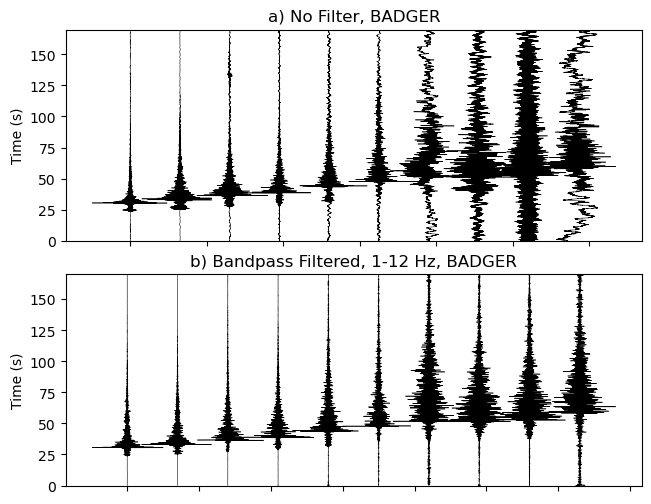

In [101]:
# Arrivals and spectrum for a local earthquake
# Event: 6/21/23, 5:08:26 UTC
from obspy.signal import filter
import obspy
import matplotlib.ticker as mticker

Ev= '2023.337.06.00.00'
EvDir= '2023.337'
sta= ['BA09','BA01','BA110','BA04','BA03','BA02','BA08','BA07','BA06','BA10'] # No BA05 during this event.
sta_names= ['HOME','KNOB','HAPP','NNIL','CLAM','COHO','KENA','SOLD','STER','NSKI']
start_time= obspy.UTCDateTime("2023-12-03T07:30:00.000Z")

fig2= plt.figure()
#ax1= fig2.add_axes([0.1, 0.72, 0.9, 0.28])
#ax2= fig2.add_axes([0.1, 0.38, 0.9, 0.28])
#ax3= fig2.add_axes([0.1, 0.04, 0.9, 0.28])
ax1= fig2.add_axes([0.1, 0.55, 0.9, 0.44])
ax2= fig2.add_axes([0.1, 0.04, 0.9, 0.44])

BB_traces1=[]; BB_traces2=[]
for i in range(0,len(sta)): #range(0,len(sta)):
    fname= '/Volumes/golos/SAC-S3/'+EvDir+'/XX.'+sta[i]+'.'+Ev+'.HHE.SAC'
    tr= read(fname, format='SAC',starttime=start_time,endtime=start_time+300)
    tr_orig= tr[0].copy()
    tr_filt= tr_orig.copy(); tr2_filt= tr_orig.copy()
    #inv= obspy.read_inventory()
    #tr.remove_response(inventory=inv)
    f= tr[0].stats.sampling_rate
    npts= tr[0].stats.npts
    BB_time= np.linspace(0,npts/f,npts)
    tr_orig.detrend('demean')
    tr_orig.normalize()
    ax1.plot(tr_orig.data+i*1.3,BB_time,linewidth=0.4,color='black')
    tr_filt.detrend('demean')
    tr_filt= tr_filt.filter("bandpass",freqmin=1.0,freqmax=5.0,corners=4,zerophase=False)
    tr_filt.normalize()
    #tr2_filt.detrend('demean')
    #tr2_filt= tr2_filt.filter("bandpass",freqmin=0.1,freqmax=12.0,corners=4,zerophase=False)
    #tr2_filt.normalize()
    ax2.plot(tr_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    #ax3.plot(tr2_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    #del tr; del tr_filt; del tr2_filt; del tr_orig
    del tr; del tr_filt; del tr_orig
    


ax1.set_ylabel('Time (s)')
ax1.set_xticklabels([])
ax1.set_ylim(0,170)
ax1.set_title('a) No Filter, BADGER')

#ax2.set_xlabel('Station')
ax2.set_ylabel('Time (s)')
ax2.set_xticklabels([])
#ax2.set_xticklabels(sta_names,rotation='vertical')
#ax2.xaxis.set_major_locator(mticker.FixedLocator(x))
ax2.set_ylim(0,170)
ax2.set_title('b) Bandpass Filtered, 1-12 Hz, BADGER')

#ax3.set_xlabel('Station')
#ax3.set_ylabel('Time (s)')
#ax3.set_xticklabels([])
#ax3.set_xticklabels(sta_names,rotation='vertical')
#ax3.xaxis.set_major_locator(mticker.FixedLocator(x))
#ax3.set_ylim(0,170)
#ax3.set_title('c) Bandpass Filtered, 0.5-12 Hz, BADGER')

plt.show()    
#tr[0].plot()
#tr[0].plot()
#
#tr_filt.plot()

fig2.savefig('Figures_data/BADGER_eqk337_1filt.png',dpi=200,bbox_inches='tight')

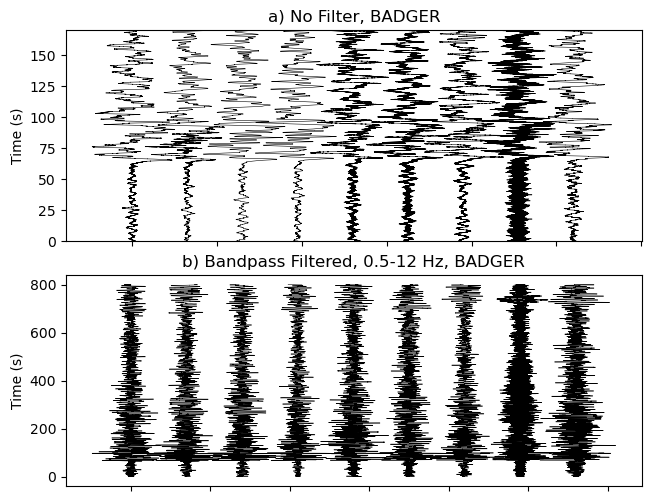

In [274]:
# Arrivals and spectrum for true teleseismic
# Event: 12/2/23, 14:37:04 UTC. The next day has regional eqk.
from obspy.signal import filter
import obspy
import matplotlib.ticker as mticker

Ev= '2023.336.14.00.00'
EvDir= '2023.336'
sta= ['BA09','BA110','BA04','BA03','BA02','BA08','BA07','BA06','BA10'] # No BA05 during this event.
sta_names= ['HOME','HAPP','NNIL','CLAM','COHO','KENA','SOLD','STER','NSKI']
start_time= obspy.UTCDateTime("2023-12-02T14:48:00.000Z")

fig2= plt.figure()
#ax1= fig2.add_axes([0.1, 0.72, 0.9, 0.28])
#ax2= fig2.add_axes([0.1, 0.38, 0.9, 0.28])
#ax3= fig2.add_axes([0.1, 0.04, 0.9, 0.28])
ax1= fig2.add_axes([0.1, 0.55, 0.9, 0.44])
ax2= fig2.add_axes([0.1, 0.04, 0.9, 0.44])

BB_traces1=[]; BB_traces2=[]
for i in range(0,len(sta)): #range(0,len(sta)):
    fname= '/Volumes/golos/SAC-S3/'+EvDir+'/XX.'+sta[i]+'.'+Ev+'.HHZ.SAC'
    tr= read(fname, format='SAC',starttime=start_time,endtime=start_time+800)
    tr_orig= tr[0].copy()
    tr_filt= tr_orig.copy(); tr2_filt= tr_orig.copy()
    #inv= obspy.read_inventory()
    #tr.remove_response(inventory=inv)
    f= tr[0].stats.sampling_rate
    npts= tr[0].stats.npts
    BB_time= np.linspace(0,npts/f,npts)
    tr_orig.detrend('demean')
    tr_orig.normalize()
    ax1.plot(tr_orig.data+i*1.3,BB_time,linewidth=0.4,color='black')
    tr_filt.detrend('demean')
    tr_filt= tr_filt.filter("bandpass",freqmin=0.1,freqmax=12.0,corners=4,zerophase=False)
    tr_filt.normalize()
    #tr2_filt.detrend('demean')
    #tr2_filt= tr2_filt.filter("bandpass",freqmin=0.1,freqmax=12.0,corners=4,zerophase=False)
    #tr2_filt.normalize()
    ax2.plot(tr_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    #ax3.plot(tr2_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    #del tr; del tr_filt; del tr2_filt; del tr_orig
    del tr; del tr_filt; del tr_orig
    


ax1.set_ylabel('Time (s)')
ax1.set_xticklabels([])
ax1.set_ylim(0,170)
ax1.set_title('a) No Filter, BADGER')

#ax2.set_xlabel('Station')
ax2.set_ylabel('Time (s)')
ax2.set_xticklabels([])
#ax2.set_xticklabels(sta_names,rotation='vertical')
#ax2.xaxis.set_major_locator(mticker.FixedLocator(x))
#ax2.set_ylim(0,170)
ax2.set_title('b) Bandpass Filtered, 0.5-12 Hz, BADGER')

#ax3.set_xlabel('Station')
#ax3.set_ylabel('Time (s)')
#ax3.set_xticklabels([])
#ax3.set_xticklabels(sta_names,rotation='vertical')
#ax3.xaxis.set_major_locator(mticker.FixedLocator(x))
#ax3.set_ylim(0,170)
#ax3.set_title('c) Bandpass Filtered, 0.5-12 Hz, BADGER')

plt.show()    
#tr[0].plot()
#tr[0].plot()
#
#tr_filt.plot()

fig2.savefig('Figures_data/BADGER_eqk336_filt.png',dpi=200,bbox_inches='tight')

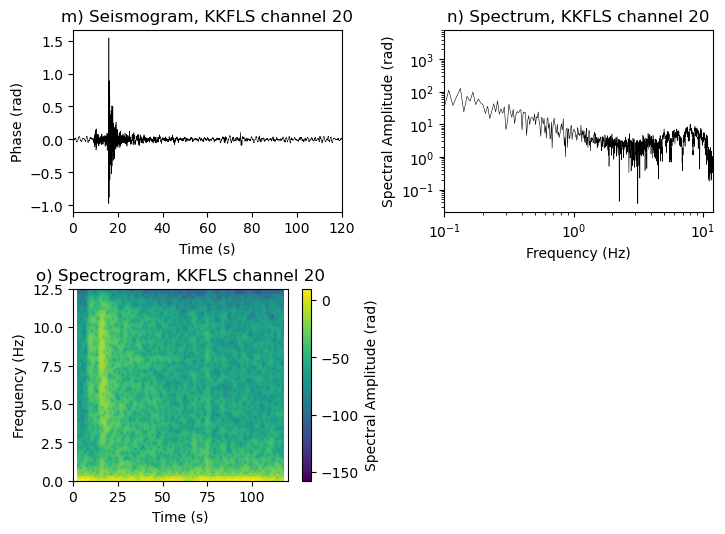

In [20]:
# Plot single DAS trace + spectrogram for eqk 337.

file = '/Users/golos/Research/Alaska/DAS/Data/2023.337/TERRA.h5'
data = h5py.File(file)
attrs=dict(data['Acquisition'].attrs)
das = np.array(data['Acquisition/Raw[0]/RawData'])
time = np.array(data['Acquisition/Raw[0]/RawDataTime'])
data.close()
dt = 1/attrs['MaximumFrequency']/2
dx = attrs['SpatialSamplingInterval']
nt,nx = das.shape

x = np.linspace(0,nx*dx,nx)
t = np.linspace(0,nt*dt,nt)

trDAS= Trace(data=das[:,20])
dtDAS= 1/attrs['MaximumFrequency']/2
trDAS.stats.sampling_rate= 1/dtDAS
trDAS.stats.starttime= attrs['MeasurementStartTime']
trDAS.stats.network = "CIDAS"

bb,ab = butter(2,[0.5,12.0],'bandpass',fs=1/dt)
data_bp = filtfilt(bb,ab,das,axis=0)

fig1= plt.figure()
ax1= fig1.add_axes([0.05, 0.61, 0.42, 0.38])
ax1.plot(t,data_bp[:,20],linewidth=0.4,color='black')
#plt.plot(t,data_hf[:,20])
# plt.plot(t,data_hf[:,4])
ax1.set_ylabel('Phase (rad)')
ax1.set_xlabel('Time (s)')
ax1.set_xlim(0, 120)
plt.title('m) Seismogram, KKFLS channel 20')


spec_DASlocal, freq_DASlocal= plot_spectrum(trDAS)
ax2= fig1.add_axes([0.63, 0.61, 0.42, 0.38])
ax2.loglog(freq_DASlocal,np.abs(spec_DASlocal),linewidth=0.4,color='black')
ax2.set_ylabel('Spectral Amplitude (rad)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_xlim(0.1, 12)
plt.title('n) Spectrum, KKFLS channel 20')

ax3= fig1.add_axes([0.05, 0.05, 0.42, 0.40])
trDAS.spectrogram(wlen=0.16/dtDAS, per_lap=0.95, dbscale=True, log=False, axes=ax3)
im= ax3.images[0]
#im.set_clim(0, 4)
fig1.colorbar(im,ax=ax3,label='Spectral Amplitude (rad)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Frequency (Hz)')
ax3.set_xlim(0,120)
ax3.set_ylim(0,12.5)
plt.title('o) Spectrogram, KKFLS channel 20')


plt.savefig('Figures_data/DAS_eqk337_atChannel20.png',dpi=200,bbox_inches='tight')

plt.show()

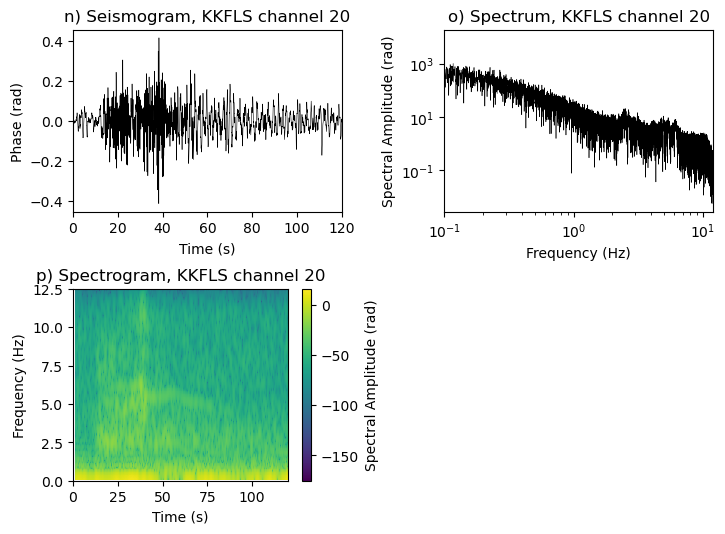

In [21]:
# Need to make DAS into a trace object.
import h5py
from scipy.signal import butter, filtfilt

# Regional event.
file = '/Users/golos/Research/Alaska/DAS/Data/2023.289/KKFLS.h5'
data = h5py.File(file)
attrs=dict(data['Acquisition'].attrs)
das = np.array(data['Acquisition/Raw[0]/RawData'])
time = np.array(data['Acquisition/Raw[0]/RawDataTime'])
data.close()
dt = 1/attrs['MaximumFrequency']/2
dx = attrs['SpatialSamplingInterval']
nt,nx = das.shape

x = np.linspace(0,nx*dx,nx)
t = np.linspace(0,nt*dt,nt)


#trDAS= Trace(data=data_bp[:,20])
trDAS= Trace(data=das[:,20])
dtDAS= 1/attrs['MaximumFrequency']/2
trDAS.stats.sampling_rate= 1/dtDAS
trDAS.stats.starttime= attrs['MeasurementStartTime']
trDAS.stats.network = "CIDAS"

bb,ab = butter(2,[0.5,12.0],'bandpass',fs=1/dt)
data_bp = filtfilt(bb,ab,das,axis=0)

fig1= plt.figure()
ax1= fig1.add_axes([0.05, 0.61, 0.42, 0.38])
ax1.plot(t,data_bp[:,20],linewidth=0.4,color='black')
#plt.plot(t,data_hf[:,20])
# plt.plot(t,data_hf[:,4])
ax1.set_ylabel('Phase (rad)')
ax1.set_xlabel('Time (s)')
ax1.set_xlim(0, 120)
plt.title('n) Seismogram, KKFLS channel 20')


spec_DASlocal, freq_DASlocal= plot_spectrum(trDAS)
ax2= fig1.add_axes([0.63, 0.61, 0.42, 0.38])
ax2.loglog(freq_DASlocal,np.abs(spec_DASlocal),linewidth=0.4,color='black')
ax2.set_ylabel('Spectral Amplitude (rad)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_xlim(0.1, 12)
plt.title('o) Spectrum, KKFLS channel 20')

ax3= fig1.add_axes([0.05, 0.05, 0.42, 0.40])
trDAS.spectrogram(wlen=0.1/dtDAS, per_lap=0.95, dbscale=True, log=False, axes=ax3)
im= ax3.images[0]
#im.set_clim(0, 4)
fig1.colorbar(im,ax=ax3,label='Spectral Amplitude (rad)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Frequency (Hz)')
ax3.set_xlim(0,120)
ax3.set_ylim(0,12.5)
plt.title('p) Spectrogram, KKFLS channel 20')


plt.savefig('Figures_data/DAS_eqk289_atChannel20.png',dpi=200,bbox_inches='tight')

plt.show()

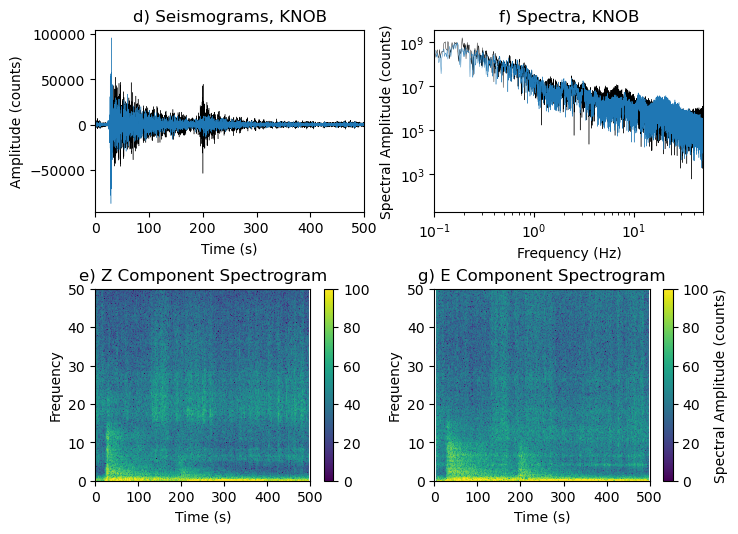

In [18]:
#Same, for broadband. Show both Z and E components.

fnameE= '/Volumes/golos/SAC-S2/2023.289/XX.BA01.2023.289.10.00.00.HHE.SAC'
fnameZ= '/Volumes/golos/SAC-S2/2023.289/XX.BA01.2023.289.10.00.00.HHZ.SAC'
start_time= obspy.UTCDateTime("2023-10-16T11:38:40.000Z") # for event 2023.289
trE= read(fnameE, format='SAC',starttime=start_time,endtime=start_time+500)
trZ= read(fnameZ, format='SAC',starttime=start_time,endtime=start_time+500)
f= trE[0].stats.sampling_rate
trE[0].detrend('demean'); trZ[0].detrend('demean')
specE_local, freqE_local= plot_spectrum(trE[0])
specZ_local, freqZ_local= plot_spectrum(trZ[0])
npts= trE[0].stats.npts
trE_filt= trE[0].copy(); trZ_filt= trZ[0].copy();
#trE_filt.detrend('demean'); trZ_filt.detrend('demean');
trE_filt= trE_filt.filter("bandpass",freqmin=1.0,freqmax=10.0,corners=4,zerophase=False)
trZ_filt= trZ_filt.filter("bandpass",freqmin=1.0,freqmax=10.0,corners=4,zerophase=False)
BB_time= np.linspace(0,npts/f,npts)


fig1= plt.figure()
ax1= fig1.add_axes([0.05, 0.61, 0.42, 0.38])
ax1.plot(BB_time,trE_filt.data,linewidth=0.3,color='black')
ax1.plot(BB_time,trZ_filt.data,linewidth=0.3)
ax1.set_xlabel('Time (s)',fontsize=10)
ax1.set_ylabel('Amplitude (counts)',fontsize=10)
ax1.set_xlim(0, 500)
plt.title("d) Seismograms, KNOB")

ax2= fig1.add_axes([0.58, 0.61, 0.42, 0.38])
ax2.loglog(freqE_local, np.abs(specE_local),linewidth=0.3,color='black')
ax2.loglog(freqZ_local, np.abs(specZ_local),linewidth=0.3)
ax2.set_xlim(0.1, 50)
#ax2.set_ylim(1, 10**9)
ax2.set_ylabel('Spectral Amplitude (counts)')
ax2.set_xlabel('Frequency (Hz)')
plt.title('f) Spectra, KNOB')

ax3= fig1.add_axes([0.05, 0.05, 0.42, 0.40])
trZ.spectrogram(wlen=5, per_lap=0.95, dbscale=True, log=False, axes=ax3)
im= ax3.images[0]
im.set_clim(0, 100)
fig1.colorbar(im,ax=ax3)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Frequency')
ax3.set_xlim(0,500)
ax3.set_ylim(0,50)
plt.title('e) Z Component Spectrogram')


ax4= fig1.add_axes([0.58, 0.05, 0.42, 0.40])
trE.spectrogram(wlen=5, per_lap=0.95, dbscale=True, log=False, axes=ax4)
im= ax4.images[0]
im.set_clim(0, 100)
fig1.colorbar(im,ax=ax4,label='Spectral Amplitude (counts)')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Frequency')
ax4.set_xlim(0,500)
ax4.set_ylim(0,50)
plt.title('g) E Component Spectrogram')

fig1.savefig('Figures_data/BADGER_eqk289_atBA01.png',dpi=200,bbox_inches='tight')
plt.show()


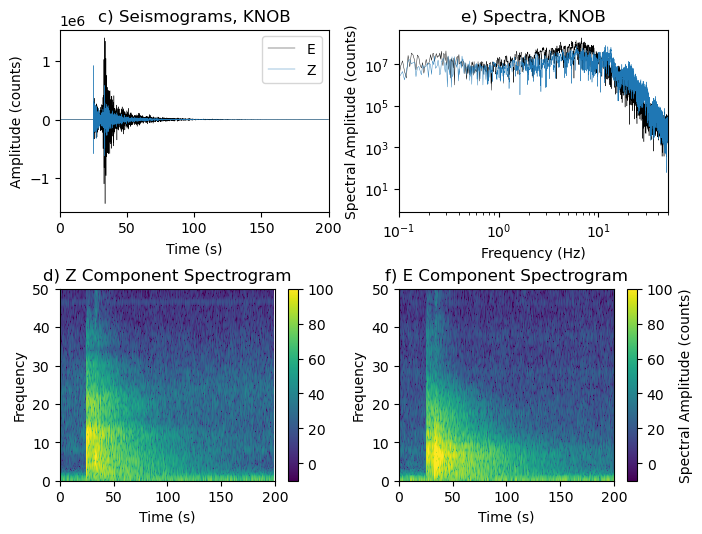

In [19]:
fnameE= '/Volumes/golos/SAC-S3/2023.337/XX.BA01.2023.337.06.00.00.HHE.SAC'
fnameZ= '/Volumes/golos/SAC-S3/2023.337/XX.BA01.2023.337.06.00.00.HHZ.SAC'
start_time= obspy.UTCDateTime("2023-12-03T07:30:00.000Z")
trE= read(fnameE, format='SAC',starttime=start_time,endtime=start_time+200)
trZ= read(fnameZ, format='SAC',starttime=start_time,endtime=start_time+200)
f= trE[0].stats.sampling_rate
trE[0].detrend('demean'); trZ[0].detrend('demean')
specE_local, freqE_local= plot_spectrum(trE[0])
specZ_local, freqZ_local= plot_spectrum(trZ[0])
npts= trE[0].stats.npts
trE_filt= trE[0].copy(); trZ_filt= trZ[0].copy();
#trE_filt.detrend('demean'); trZ_filt.detrend('demean');
trE_filt= trE_filt.filter("bandpass",freqmin=1.0,freqmax=10.0,corners=4,zerophase=False)
trZ_filt= trZ_filt.filter("bandpass",freqmin=1.0,freqmax=10.0,corners=4,zerophase=False)
BB_time= np.linspace(0,npts/f,npts)


fig1= plt.figure()
ax1= fig1.add_axes([0.05, 0.61, 0.42, 0.38])
ax1.plot(BB_time,trE_filt.data,linewidth=0.3,color='black',label='E')
ax1.plot(BB_time,trZ_filt.data,linewidth=0.3,label='Z')
ax1.set_xlabel('Time (s)',fontsize=10)
ax1.set_ylabel('Amplitude (counts)',fontsize=10)
ax1.set_xlim(0, 200)
plt.title("c) Seismograms, KNOB")
plt.legend()

ax2= fig1.add_axes([0.58, 0.61, 0.42, 0.38])
ax2.loglog(freqE_local, np.abs(specE_local),linewidth=0.3,color='black')
ax2.loglog(freqZ_local, np.abs(specZ_local),linewidth=0.3)
ax2.set_xlim(0.1, 50)
#ax2.set_ylim(1, 10**9)
ax2.set_ylabel('Spectral Amplitude (counts)')
ax2.set_xlabel('Frequency (Hz)')
plt.title('e) Spectra, KNOB')

ax3= fig1.add_axes([0.05, 0.05, 0.42, 0.40])
trZ.spectrogram(wlen=1, per_lap=0.95, dbscale=True, log=False, axes=ax3)
im= ax3.images[0]
im.set_clim(-10, 100)
fig1.colorbar(im,ax=ax3)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Frequency')
ax3.set_xlim(0,200)
ax3.set_ylim(0,50)
plt.title('d) Z Component Spectrogram')


ax4= fig1.add_axes([0.58, 0.05, 0.42, 0.40])
trE.spectrogram(wlen=1, per_lap=0.95, dbscale=True, log=False, axes=ax4)
im= ax4.images[0]
im.set_clim(-10, 100)
fig1.colorbar(im,ax=ax4,label='Spectral Amplitude (counts)')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Frequency')
ax4.set_xlim(0,200)
ax4.set_ylim(0,50)
plt.title('f) E Component Spectrogram')

fig1.savefig('Figures_data/BADGER_eqk337_atBA01.png',dpi=200,bbox_inches='tight')


In [ ]:
# Regional earthquake, Andreanof, AK
# Event: 10/16/23, 
from obspy.signal import filter
import obspy
import matplotlib.ticker as mticker

Ev= '2023.289.10.00.00'
EvDir= '2023.289'
sta= ['BA01','BA05','BA110','BA04','BA03','BA02','BA06','BA10'] # No BA05 during this event.
sta_names= ['KNOB','ANCH','HAPP','NNIL','CLAM','COHO','STER','NSKI']
#start_time= obspy.UTCDateTime("2023-12-03T07:30:00.000Z") # for event 2023.337
start_time= obspy.UTCDateTime("2023-10-16T11:38:40.000Z") # for event 2023.289

fig2= plt.figure()
ax1= fig2.add_axes([0.1, 0.72, 0.9, 0.28])
ax2= fig2.add_axes([0.1, 0.38, 0.9, 0.28])
ax3= fig2.add_axes([0.1, 0.04, 0.9, 0.28])

BB_traces1=[]; BB_traces2=[]
for i in range(0,len(sta)): #range(0,len(sta)):
    fname= '/Volumes/golos/SAC-S2/'+EvDir+'/XX.'+sta[i]+'.'+Ev+'.HHE.SAC'
    tr= read(fname, format='SAC',starttime=start_time,endtime=start_time+500)
    tr_orig= tr[0].copy()
    tr_filt= tr_orig.copy(); tr2_filt= tr_orig.copy()
    #inv= obspy.read_inventory()
    #tr.remove_response(inventory=inv)
    f= tr[0].stats.sampling_rate
    npts= tr[0].stats.npts
    BB_time= np.linspace(0,npts/f,npts)
    tr_orig.detrend('demean')
    tr_orig.normalize()
    ax1.plot(tr_orig.data+i*1.3,BB_time,linewidth=0.4,color='black')
    tr_filt.detrend('demean')
    tr_filt= tr_filt.filter("bandpass",freqmin=1.0,freqmax=5.0,corners=4,zerophase=False)
    tr_filt.normalize()
    tr2_filt.detrend('demean')
    tr2_filt= tr2_filt.filter("bandpass",freqmin=0.1,freqmax=12.0,corners=4,zerophase=False)
    tr2_filt.normalize()
    ax2.plot(tr_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    ax3.plot(tr2_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    del tr; del tr_filt; del tr2_filt; del tr_orig
    


ax1.set_ylabel('Time (s)')
ax1.set_xticklabels([])
ax1.set_ylim(0,500)
ax1.set_title('a) No Filter, BADGER')

#ax2.set_xlabel('Station')
ax2.set_ylabel('Time (s)')
ax2.set_xticklabels([])
#ax2.set_xticklabels(sta_names,rotation='vertical')
#ax2.xaxis.set_major_locator(mticker.FixedLocator(x))
ax2.set_ylim(0,500)
ax2.set_title('b) Bandpass Filtered, 1-12 Hz, BADGER')

#ax3.set_xlabel('Station')
ax3.set_ylabel('Time (s)')
ax3.set_xticklabels([])
#ax3.set_xticklabels(sta_names,rotation='vertical')
#ax3.xaxis.set_major_locator(mticker.FixedLocator(x))
ax3.set_ylim(0,500)
ax3.set_title('c) Bandpass Filtered, 0.5-12 Hz, BADGER')

plt.show()    
#tr[0].plot()
#
#tr_filt.plot()

fig2.savefig('Figures_data/BADGER_eqk289.png',dpi=200,bbox_inches='tight')